# Common utilities

Module [majordome.common](common.md) provides a set of utilities that are whether too general purpose for integrating another module or still waiting to find their definitive home. These include constants, type aliases, and functionalities of different kinds. Regarding this last kind of components, this tutorial aims at illustrating their use for practical documentation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import majordome.common as mc
import numpy as np

## *NormalFlowRate*

Common daily work activity for the process engineer is to perform mass balances, but wait, ..., gas flow rates are generally provided under normal conditions, and compositions may vary, so you need to compute normal densities first... whatever. This class provides a calculator wrapping a Cantera solution object so that your life gets easier.

Its simples use case is as follows:

In [3]:
nfr = mc.NormalFlowRate("airish.yaml")
print(f"Convert 1000 Nm³/h to {nfr(1000.0):.5f} kg/s")

Convert 1000 Nm³/h to 0.35903 kg/s


If the database file default composition does not suit you, no problems:

In [4]:
nfr = mc.NormalFlowRate("airish.yaml", X="N2: 1")
print(f"Convert 1000 Nm³/h to {nfr(1000.0):.5f} kg/s")

Convert 1000 Nm³/h to 0.34718 kg/s


You can also print a nice report to inspect the details of internal state. For more, please check its documentation at the [API page](common.md).

In [5]:
print(nfr.report())

|------------------------|----------|--------------|
| Temperature            | K        |    273.15    |
| Pressure               | Pa       | 101325       |
| Density                | kg/m³    |      1.24985 |
| Specific enthalpy      | J/(kg.K) | -25864.9     |
| Specific heat capacity | J/(kg.K) |   1035.52    |
| mass: N2               | -        |      1       |


## *ReadTextData*

WIP, sorry for the inconvenience...

## *StandardPlot*

WIP, sorry for the inconvenience...

## *InteractiveSession*

WIP, sorry for the inconvenience...

## *RelaxUpdate* and *StabilizeNvarsConvergenceCheck*

Simplest of relaxation methods; assume you have a new updated solution $A_{new}^{\star}$ for a problem whose past state was $A_{old}$, then the manager will ensure the following relaxation will be applied to compute the next solution state $A_{new}$ to be used in whatever you are computing:

$$
\begin{align}
A_{new} &= \alpha{}A_{old} + (1-\alpha)A_{new}^{\star}\\
A_{old} &= A_{new}
\end{align}
$$

Notice that in this formulation, $\alpha$ (or `alpha` in the API) represents the fraction of old solution to be used in the *smearing* process. Below we illustrate the effect of a step function $H$ valued at `10` from the begining over consecutive updates (here we do not test for convergence, as that is problem specific and for this simple case the required number of steps could be evaluated by hand, take some time to try!).

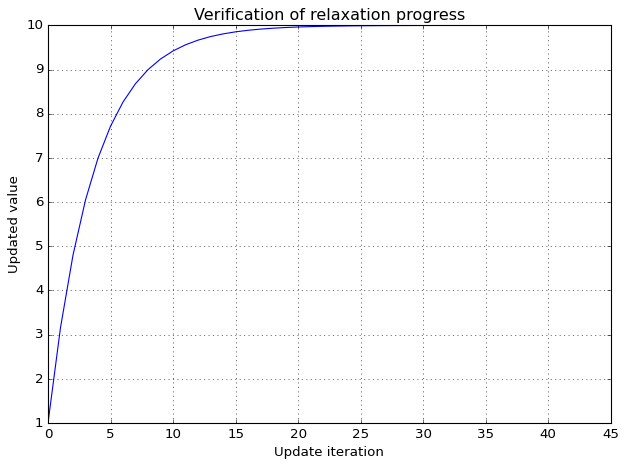

In [6]:
alpha = 0.76
niter = 200

single = np.ones(1)
relaxer = mc.RelaxUpdate(single, alpha)

converged = mc.StabilizeNvarsConvergenceCheck(niter, patience=3, n_vars=1)

history = np.zeros(niter+1)
history[0] = single[0]

H = np.asarray([10])

for n in range(niter):
    single[:] = relaxer(H)
    history[n+1] = single[0]

    if converged(single[0]):
        history = history[:n+2]
        break

@mc.standard_plot()
def plot_history(history, fig, ax):
    ax[0].plot(history)
    ax[0].set_title("Verification of relaxation progress")
    ax[0].set_xlabel("Update iteration")
    ax[0].set_ylabel("Updated value")

_ = plot_history(history)